# Predicting the 2026 FIFA World Cup
Project mentor:

Jonathan Locala, Simon Turner


# Outline and Deliverables

Our proposal grouped deliverables into Must, Expect, and Stretch tiers. Below we list each one, what we actually did, and where it lives in this notebook.

### Completed Deliverables
1. **Full feature pipeline merging all data sources** *(Must)* — 31 base features over seven groups (trailing form, head-to-head, Elo, FIFA rank, squad value, position z-scores, venue), plus 31 missingness-indicator columns. See the [Pre-processing](#Pre-processing) and [Methods](#Methods) sections.
2. **Logistic regression baseline** *(Must)* — multinomial LR with L2 regularization and class-balanced weights. See [Methods](#Methods).
3. **Random forest model** *(Must / Expect)* — 200 trees, class-balanced subsampling, hyperparameters chosen from a 30-config grid. See [Methods](#Methods).
4. **XGBoost model** *(Expect)* — gradient boosting, 12-config grid. See [Methods](#Methods).
5. **Ablation study** *(Expect)* — leave-one-feature-group-out, retrained for each. See [Results](#Results).
6. **Feature importance plots** *(Expect)* — built-in importances for all three models. See [Results](#Results).
7. **Position-aware player stat features** *(Stretch)* — we went well beyond a single z-score normalisation. We built a four-tier source cascade (Understat → Transfermarkt seasons → fotmob → fbref) so each cohort player at each match date is normalised within their own league-season pool, with a position-blind aggregation that we discuss in [Pre-processing](#Pre-processing).
8. **Group-stage predictions for the 72 2026 World Cup matches** *(Must)* — every group-stage fixture has a complete feature row and a calibrated prediction. See [Tournament simulation](#Tournament-simulation).
9. **Full knockout-bracket simulation** *(Expect)* — 32-team single-elim Monte Carlo with live Elo updates between matches. The bracket follows FIFA's published 2026 structure (specific R32 slot pairings keyed by group position, plus eight third-place slots filled by bipartite matching against eligibility lists). See [Tournament simulation](#Tournament-simulation).
10. **Penalty-shootout tiebreakers** *(part of Expect)* — knockout draws are resolved by a per-team shootout model using current-season fbref penalty data: top-5 takers' conversion rate vs opposing GK save rate, with empirical-Bayes shrinkage on the GK side to handle small-sample noise. Three-tier fallback when teams have insufficient Big-5 data. See [Tournament simulation](#Tournament-simulation).

### Uncompleted Deliverables
1. **Small feedforward neural network** *(Stretch)* — we decided not to pursue this. With ~11 thousand training matches and noisy outcomes, the LR/RF/XGB ensemble was already in the same band as published bookmaker odds and FiveThirtyEight models, and our bias-variance evidence suggests the ceiling is data variance rather than model capacity.
2. **Post-tournament validation** *(Stretch)* — the 2026 World Cup begins in June 2026, after this submission. We can validate the model's group-stage predictions against actual outcomes once the tournament is played.

### Additional Work (beyond the proposal)
Several lines of work weren't in the original proposal but became important once we got into the data:

1. **Date-correct tournament-squad scraper** — we scraped 44 editions of major tournaments (World Cup, Euro, Copa, AFCON, Asian Cup, Gold Cup, OFC, Confederations Cup) from Transfermarkt to build per-match cohorts. This replaced an earlier, anachronistic cohort built from current squad rosters. See [Pre-processing](#Pre-processing) and `src/scrape_tournaments.py`.
2. **Four-source player-stat scraping** — Understat, fotmob, Transfermarkt scorerlist, and fbref. Each source covers a different time period and league set, and combining them required overcoming Cloudflare protection on some sites and finding internal API endpoints on others.
3. **Probability calibration via isotonic regression** — applied to all three models. Wasn't in the proposal but matters here because the simulation samples *from* the probabilities rather than just looking at argmax.
4. **Soft-voting ensemble** — equal-weighted average of the three calibrated models, exposed as a single `SoftVoteEnsemble` class in `src/ensemble.py` so the simulation can load one file and call `predict_proba`.
5. **Held-out test-set evaluation** — keeping the test split untouched during tuning gave us an honest out-of-sample number rather than a tuning-optimistic one. See [Results](#Results).
6. **FIFA-accurate knockout structure** — instead of a generic seeded bracket, we encoded FIFA's official 2026 bracket pairings (16 R32 slot specs from FIFA's published bracket, the R16/QF/SF/Final pairing tree, and bipartite matching to slot the eight 3rd-place teams while respecting FIFA's eligibility constraints).

# Preliminaries

## What problem were you trying to solve or understand?

We're predicting the outcome of international football matches as a three-class problem (home win, draw, away win) and using those per-match probabilities to simulate the 2026 FIFA World Cup. The match-level model is the foundation; the simulation is the application. Both pieces matter, because the metric a tournament organiser, broadcaster, or bookmaker actually cares about isn't "did you call this match correctly" but "what's the probability Brazil reaches the semi-final," and getting from the first question to the second requires a probability-calibrated model and an outcome simulator that respects the structure of the tournament.

The real-world implications are easy to point at. Sports betting is a multi-billion-dollar industry, and bookmaker odds are themselves implicit probability predictions over the same outcome space; published predictive models like FiveThirtyEight's get cited in news coverage and influence fan discussion. Less obviously, federations and broadcasters use simulations to plan logistics around likely-vs-long-shot scenarios, and the same techniques transfer cleanly to other tournament-structured problems (NCAA brackets, playoff modelling, qualification pathways).

This problem looks at first like a textbook supervised classification task — three classes, a feature matrix, a label — and that framing carried us through most of the modelling decisions. Multinomial logistic regression, random forests, gradient boosting, hyperparameter tuning by grid search, k-fold ideas adapted to a chronological setting: all of these mapped directly onto things we covered in lectures and breakouts. What's unique is everything around the model. The label distribution is imbalanced and the minority class (draws) is the hardest to predict because, mechanically, a draw is what happens when neither team's signal dominates rather than something with a positive predictive signal of its own. Most matches in the dataset have very little head-to-head history (international fixtures are sparse), so features that work well for club football often have ~38% coverage on World Cup group draws. Many of the most useful player-stat sources only cover the Big-5 European leagues, so getting historical data on, say, Saudi Pro League squads in 2014 required scraping multiple sites and accepting trade-offs between date-correctness and league coverage.

There are real ethical considerations. The most obvious is that any predictive model in this domain risks amplifying gambling-related harm, even when it's built for non-betting purposes. Less obvious is the bias baked into our data sources: player-quality features come overwhelmingly from European leagues, which means African, Asian, and CONCACAF teams are systematically described less richly than European or South American teams in our feature matrix. We try to mitigate this with the multi-tier source cascade (which adds non-Big-5 leagues via fotmob and Transfermarkt seasons), but it doesn't fully close the gap. Any model deployed for real bracket-prediction or odds-setting use should make this representation gap explicit, not paper over it.

## Dataset(s)

We assembled a feature matrix from eight datasets, four from public sources (Kaggle and a published academic database) and four that we scraped ourselves. The public sources gave us match outcomes, FIFA rankings, World Cup–specific structure, and historical player valuations going back to 2000. Our own scrapes filled in the gaps that no public dataset covered: which exact players appeared for which national team at which tournament, and per-season player performance statistics across the Big-5 European leagues plus seven major non-Big-5 leagues.

Match outcomes come from `results.csv` (49,008 international matches from 1872 to mid-2024, originally compiled by github user martj42 and published on Kaggle). FIFA rankings come from the same Kaggle space (`fifa_ranking-2024-06-20.csv`, 333 ranking dates). Tournament-specific data — squad rosters, manager appointments, group standings — comes from the Fjelstul World Cup Database, an academic dataset with clean Wikipedia-derived values. Historical player valuations come from the davidcariboo/player-scores Kaggle dataset, which scrapes Transfermarkt's transfer-value history; this gives us 616k records from 2000 to 2026.

Our own scrapes were necessary because no public dataset connects "what was Brazil's actual 2014 World Cup squad" to "what was each of those player's xG and assists per 90 in their club season that year." We scraped 44 tournaments since 2006 (eight tournament families, including the Confederations Cup, OFC Nations Cup, and confederation championships) for 38,792 player-rows, with 100% coverage of the 2026 World Cup squads. We then built four player-stat scrapers: Understat for advanced stats in the Big 5 plus the Russian Premier League (29,800 player-seasons since 2014), Transfermarkt scorer-list for basic goals/assists across 12 leagues 2008–2024 (5,100 player-seasons), fotmob for current-season multi-league data (6,427 player-seasons, twelve leagues including MLS, Saudi Pro, Liga MX, Brasileirão, and the Eredivisie), and fbref via soccerdata for defensive misc-table stats. Each scraper was non-trivial: Understat had changed its page structure recently and required reverse-engineering an internal `getLeagueData` endpoint; fbref had stripped most advanced stats from public HTML; fotmob required finding their CDN endpoint; Transfermarkt required Selenium with undetected-chromedriver to bypass Cloudflare for the squad pages.

We chose this combination because it lets us answer a question the more standard datasets cannot: at the date a particular World Cup match was played, which exact players were on each team, and how were each of those players actually performing in their club competition at that time? That precision matters more than we initially appreciated — a naive cohort built from current squad rosters would credit teams in 2010 with players who were toddlers at the time.

In [1]:
import sys, os
# Make src/ importable from the notebook so we can use prepare_features etc.
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

DATA_PROC = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

# Load the assembled feature matrix and show two example rows.
features = pd.read_csv(os.path.join(DATA_PROC, "features.csv"))
print(f"features.csv: {len(features):,} rows x {features.shape[1]} columns")
print(f"Splits: {features['split'].value_counts().to_dict()}\n")

# Two example rows: one historical match (label known), one 2026 WC match (label NaN).
example_cols = ["date", "home_team", "away_team", "neutral", "label", "split",
                "elo_diff", "fifa_rank_diff", "home_squad_value", "away_squad_value"]
display(features[features["split"] == "train"][example_cols].head(1))
display(features[features["split"] == "predict"][example_cols].head(1))

features.csv: 15,704 rows x 45 columns
Splits: {'train': 11218, 'val': 3252, 'test': 1162, 'predict': 72}



,date,home_team,away_team,neutral,label,split,elo_diff,fifa_rank_diff,home_squad_value,away_squad_value
0,2010-01-02,Iran,North Korea,True,2.0,train,72.558506,-22.0,4000000.0,NaN


,date,home_team,away_team,neutral,label,split,elo_diff,fifa_rank_diff,home_squad_value,away_squad_value
15632,2026-06-11,Mexico,South Africa,False,NaN,predict,302.378867,-44.0,406050000.0,22850000.0


## Pre-processing

We landed on 31 base features grouped into seven families: trailing form (last-10 win rate, goals for, goals against per side), head-to-head win rate, Elo (per side and difference), FIFA rank (per side and difference), squad value (cohort total, top-26 sum, average, size, per side and differences), position z-scores (attacking, creating, defending per side and differences), and a binary neutral-venue flag. Every feature is continuous numeric except `neutral`, so we don't do any one-hot encoding or categorical preprocessing.

We chose those seven families because they each capture a distinct signal: form is recent performance, h2h is matchup-specific history, Elo is a quality estimate that updates after every match in a way that respects opponent strength, FIFA rank is a globally standardised ranking that's coarser but less reactive than Elo, squad value is a market-implied talent measure, position z-scores are a sport-specific talent measure normalised within a player's own league-season, and the neutral flag tells the model whether home advantage applies. The two features we explicitly *dropped* both went through the pipeline before we removed them: average international caps and manager tenure. Caps came out of our ablation study as the only feature group whose removal slightly *improved* log loss — its information content was already captured by squad value (experienced players play for valuable clubs), and the noise it added was hurting more than the signal helped. Manager tenure came from the Fjelstul database, which doesn't include start/end dates for managerial appointments — we tried a four-year-bucketed approximation and found it was too coarse to be informative, so we cut it.

The label distribution is imbalanced: roughly 47% home wins, 23% draws, 30% away wins. We addressed this two ways. First, we report macro F1 alongside accuracy in every results table; macro F1 averages per-class F1 with equal weight, so a model that ignores draws gets penalised regardless of how often draws are the majority. Second, we pass `class_weight="balanced"` to logistic regression and random forest, and `sample_weight=compute_sample_weight("balanced", y)` to XGBoost. These nudge the model to allocate predictive capacity toward the minority class even when the majority class is "easier" to predict by base rate.

Missing data was the single biggest pre-processing challenge. Several feature groups have legitimate NaN at certain dates: head-to-head has no value for first meetings (38% of 2026 World Cup group fixtures are first meetings), squad-value features are NaN for cohorts where no Transfermarkt data exists, position z-scores are NaN for players outside any covered league. Our strategy was to add a binary missingness indicator for every feature with any NaN in train, val, or test, then median-impute the underlying value with medians computed from the training split only (so test medians don't leak into training). The indicator columns let the model learn separate effects for "this value is genuinely 0.5 vs the league average" and "this value was missing and we filled it in." We end up with 31 base features plus 31 missingness indicators, for 62 total columns into the model.

We didn't do explicit outlier handling. Tree-based models are robust to outlier scaling, and for logistic regression we apply scikit-learn's `StandardScaler` which makes the linear decision boundary insensitive to feature scale but doesn't truncate values. Two features that look outlier-prone — squad value and FIFA rank — are exactly where extreme values are signal rather than noise (Brazil really does have a far higher squad value than San Marino, and that's the whole point), so we leave them in their raw scale and let the scaler handle them.

In [2]:
from models import prepare_features

X_train, X_val, X_test, Y_train, Y_val, Y_test, feature_names, fill_values = prepare_features(features)

print(f"X_train: {X_train.shape}   X_val: {X_val.shape}   X_test: {X_test.shape}")
print(f"Total features: {len(feature_names)} ("
      f"{sum(1 for c in feature_names if not c.endswith('_missing'))} base "
      f"+ {sum(1 for c in feature_names if c.endswith('_missing'))} missingness flags)")
print(f"\nLabel distribution (train): "
      f"home_win={int((Y_train==2).sum())}  draw={int((Y_train==1).sum())}  away_win={int((Y_train==0).sum())}")
print(f"Class proportions:             "
      f"home_win={(Y_train==2).mean():.1%}  draw={(Y_train==1).mean():.1%}  away_win={(Y_train==0).mean():.1%}")
display(X_train.iloc[:1, :12])

X_train: (11218, 62)   X_val: (3252, 62)   X_test: (1162, 62)
Total features: 62 (33 base + 29 missingness flags)

Label distribution (train): home_win=5367  draw=2619  away_win=3232
Class proportions:             home_win=47.8%  draw=23.3%  away_win=28.8%


,attacking_z_diff,away_attacking_z,away_avg_value,away_creating_z,away_defending_z,away_elo,away_fifa_rank,away_form_ga,away_form_gf,away_form_win_rate,away_squad_size,away_squad_value
0,0.085261,0.426003,2.564966e+06,0.288488,0.121914,1651.278476,86.0,1.2,1.2,0.4,25.0,59812500.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = pd.Series(Y_train).value_counts().sort_index()
axes[0].bar(["away_win", "draw", "home_win"], [counts.get(0,0), counts.get(1,0), counts.get(2,0)],
            color=["tab:red", "tab:gray", "tab:green"])
axes[0].set_title("Training-set class distribution")
axes[0].set_ylabel("matches")
for i, v in enumerate([counts.get(0,0), counts.get(1,0), counts.get(2,0)]):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(Y_train):.1%})", ha="center", fontsize=9)

# Elo diff distribution by class — the dominant single signal
elo_train = features.loc[features["split"] == "train", ["elo_diff", "label"]].dropna()
for label, name, color in [(2, "home_win", "tab:green"), (1, "draw", "tab:gray"), (0, "away_win", "tab:red")]:
    axes[1].hist(elo_train.loc[elo_train["label"]==label, "elo_diff"], bins=40,
                 alpha=0.5, label=name, color=color, density=True)
axes[1].set_title("elo_diff distribution by outcome (train)")
axes[1].set_xlabel("home_elo - away_elo")
axes[1].legend()
plt.tight_layout()
plt.show()

/var/folders/yc/995nmk8s0vq708g9xgjsgdjw0000gn/T/ipykernel_65549/2723173920.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Models and Evaluation

## Experimental Setup

We evaluate every model on three metrics. Accuracy is the most intuitive — what fraction of matches did the top-pick prediction match the actual outcome — but it ignores how confident the model was, and it can be inflated by always predicting the majority class. Macro F1 fixes that by averaging per-class F1 with equal weight, so it punishes models that ignore the minority class even when that minority is small. Log loss is the most useful for our downstream consumer, the bracket simulation, because it measures how well-calibrated the predicted probabilities are: a model that says "60% home win" and is right gets a smaller penalty than a model that says "95% home win" and is wrong, and Monte Carlo sampling over those probabilities only produces realistic bracket statistics if the probabilities themselves are honest. Reporting all three lets us tell different parts of the story without cherry-picking.

For loss functions, each model uses the natural choice for its family. Logistic regression minimises cross-entropy with L2 regularisation, with the regularisation strength controlled by `C` (smaller C = stronger regularisation). Random forest doesn't have a single global loss — each tree is grown by minimising Gini impurity at each split — but at the forest level the prediction is a probability average, which behaves like an empirical Bayes posterior. XGBoost minimises `multi:softprob` (cross-entropy on softmax outputs) and we use `mlogloss` as the eval metric. We didn't try alternative loss functions like hinge loss because hinge doesn't produce calibrated probabilities, and probabilities are the whole point — even a perfect-accuracy hinge classifier would be useless to the simulator.

Our train/val/test split is strictly chronological: train is 2010 through end-of-2021 (11,218 matches), val is 2022 through 2024 (3,252), test is 2025 through early-2026 (1,162), and predict is the 72 group-stage fixtures of the 2026 World Cup (label unknown). We chose chronological splits, not random, because the entire forecasting setup assumes the model is built on past matches and applied to future matches. A random split would put 2024 and 2018 matches in the same training fold and let the model implicitly learn from the future. This is the same discipline we'd use for any time-series forecasting problem; the standard k-fold cross-validation we covered for general supervised learning has to be replaced with rolling-origin CV in this setting, and we discuss the trade-off we made in [Discussion](#what-youve-learned).

We added one more piece of methodological discipline that we hadn't appreciated when we wrote the proposal. After running 47 hyperparameter configs total against the val set and selecting the best, val performance becomes mildly optimistic — we're implicitly fitting model selection to val noise. The honest correction is to keep test entirely untouched during tuning and report the test number as the headline. We do that throughout this notebook.

In [4]:
# Helper for displaying the per-model metrics tables consistently below.
def metrics_row(name, probs, preds, y):
    from sklearn.metrics import accuracy_score, f1_score, log_loss
    return {
        "model": name,
        "accuracy": accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro"),
        "log_loss": log_loss(y, probs, labels=[0, 1, 2]),
    }

# All metrics are recomputed live in the [Results](#Results) cells below from
# the artefacts under models/. The training and tuning code itself lives in
# src/models.py — see the repo for the loss-function and grid-search details.
print(open(os.path.join(PROJECT_ROOT, 'METHODOLOGY.md')).read().split('## 2. Feature engineering')[0][:1200])

# Methodology

This document records the modeling decisions made for the CS475/675 World Cup
Predictor project, with enough detail to defend each choice in the final
report. It picks up where `README.md` and `DATA.md` leave off.

## 1. Pipeline overview

```
data/raw/  ──►  src/features.py  ──►  data/processed/features.csv
                                       │
                                       ▼
                                 src/models.py
                                       │
                                       ├──► models/{lr,rf,xgb}.pkl     (calibrated)
                                       ├──► models/{lr,rf,xgb}_raw.pkl (uncalibrated)
                                       ├──► models/scaler.pkl
                                       ├──► models/fill_values.pkl
                                       ├──► models/feature_names.pkl
                                       ├──► models/{summary,best_params,
                                       │            tuning_log,a

## Baselines

We compared our models against four reasonable baselines. The first three are trivial-but-honest floor checks: a uniform random guess across three classes (log loss = ln 3 ≈ 1.099), a majority-class predictor that always picks home win (~47% accuracy on val, log loss ~1.05), and a class-prior predictor that always outputs the empirical class proportions as its probability vector regardless of features (log loss ~0.99, accuracy equal to majority-class). These three establish what "no signal" looks like; any model worth keeping should beat all three on every metric.

The two stronger baselines are FiveThirtyEight's published Soccer Power Index–based World Cup model and Pinnacle's bookmaker odds for international matches. FiveThirtyEight's 2022 World Cup model ran at roughly 1.00 log loss on group-stage matches, which is the same ballpark as the class-prior baseline because international football is genuinely hard. Pinnacle's de-vigged implied probabilities sit at 0.95–1.00 log loss for international fixtures depending on the period. These are the apples-to-apples comparisons; bookmakers in particular have access to lineup news, injury reports, and weather conditions that we don't, so beating them isn't realistic — being in their range means we're in the published-model band.

We did look at related work to choose our methods. Two approaches in the published literature stand out and we considered both. The Dixon-Coles model (1997, *JRSS-C*) is the canonical Poisson goal-count model for football, and it's particularly well-suited to predicting goal margins for tiebreakers. We chose not to implement it because Poisson regression wasn't covered in lecture, and the rubric explicitly weights "appropriate use of models discussed in class" highly. We use Elo as a feature — borrowing the methodology from eloratings.net, which is itself a refinement of the original Elo system with tournament-tier-dependent K-factors and a goal-difference multiplier — but we don't treat Elo as a model in itself, just as one signal among many.

## Methods

We built three models in parallel — multinomial logistic regression, random forest, and XGBoost — plus a calibrated soft-voting ensemble that averages their probability outputs. The choice of all three is deliberate. Logistic regression gives us a fully-interpretable linear baseline whose coefficients tell us the direction and rough magnitude of each feature's effect. Random forest lets us model non-linear interactions between features without specifying them in advance, and gives stable feature importances by averaging over trees. XGBoost is the boosted-tree counterpart that often performs better on tabular data with many features, but as we'll see, its real advantage in our setting was a different one: it was the only single model that meaningfully predicts draws.

For each model, we ran a small grid search on the validation set. Logistic regression was tuned over `C ∈ {0.01, 0.1, 1, 10, 100}` (5 configs); random forest over `n_estimators ∈ {200, 500}` × `max_depth ∈ {None, 15, 25}` × `min_samples_leaf ∈ {1, 2, 5, 10, 20}` (30 configs); XGBoost over `n_estimators ∈ {300, 500}` × `max_depth ∈ {4, 6, 8}` × `learning_rate ∈ {0.05, 0.1}` (12 configs). The selection score we minimised wasn't pure log loss or pure macro F1 — it was `log_loss − 0.5 × macro_F1`, which combines a probability-quality measure with a class-balance measure. This was deliberate: a config that minimised log loss alone tended to collapse onto predicting home win, getting decent log loss because it's confidently right on the majority class, but with terrible draw recall. The combined score nudged the search toward configs that were probabilistically well-calibrated *and* didn't ignore draws.

The chosen configs are themselves informative. Logistic regression picked `C=0.01` (heavy regularisation), and across the entire C grid log loss varied by less than 0.001 — telling us the linear decision boundary is the limiting factor for LR, not the regulariser. Random forest picked `n_estimators=200, max_depth=25, min_samples_leaf=5`. After our first run picked `min_samples_leaf=5` at the conservative edge of the original grid {1,2,5}, we widened to {1,2,5,10,20} and re-ran; 5 was still chosen, confirming the original choice wasn't a grid-bound artefact. XGBoost picked the most regularised of its 12 configs (`max_depth=4, learning_rate=0.05, n_estimators=300`), and at the other end of the grid (`max_depth=8, lr=0.1`) log loss exploded to 1.05, so XGBoost was clearly the most sensitive of the three to hyperparameters.

After tuning, we wrapped each best model with `CalibratedClassifierCV(method="isotonic", cv=5)`. This fits an isotonic regression per class on top of the model's probability output, using 5-fold cross-validation on the training data, and the resulting calibrated model is what we save and what the simulator consumes. Tree-based models tend to be over-confident, while LR with `class_weight="balanced"` tends to be slightly under-confident on the majority class; calibration smooths both biases out without changing argmax accuracy meaningfully. The soft-voting ensemble is then a simple equal-weighted average of the three calibrated probability vectors per match, exposed as a single picklable `SoftVoteEnsemble` class so the simulator can swap it in like any sklearn classifier.

In terms of difficulty, LR was the easiest to implement and train (instant fit, deterministic, zero hyperparameter drama), random forest was middle-of-the-road (slightly slower but trivially parallelisable, robust to defaults), and XGBoost was the hardest — not because the API is complex, but because the model is sensitive enough that bad hyperparameters produced obviously-overfit results, and we had to be deliberate about pairing low learning rates with shallow trees to keep it useful.

In [5]:
# The training, tuning, calibration, and ablation code lives in src/models.py.
# Running `python src/models.py` regenerates everything below.
# Here we just load the trained artefacts.

import joblib
lr_cal = joblib.load(os.path.join(MODELS_DIR, "lr.pkl"))
rf_cal = joblib.load(os.path.join(MODELS_DIR, "rf.pkl"))
xgb_cal = joblib.load(os.path.join(MODELS_DIR, "xgb.pkl"))
ensemble = joblib.load(os.path.join(MODELS_DIR, "ensemble.pkl"))
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))
best_params = json.load(open(os.path.join(MODELS_DIR, "best_params.json")))

print("Best hyperparameters:")
for model, params in best_params.items():
    print(f"  {model:<22} {params}")

Best hyperparameters:
  logistic_regression    {'C': 0.01}
  random_forest          {'n_estimators': 200, 'max_depth': 25, 'min_samples_leaf': 5}
  xgboost                {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}


In [6]:
# Hyperparameter sensitivity for XGBoost — the most sensitive of the three.
# Plot val log loss across the 12 configs to show how much the choice mattered.
tuning_log = json.load(open(os.path.join(MODELS_DIR, "tuning_log.json")))
xgb_log = pd.DataFrame(tuning_log["xgboost"])
xgb_log["config"] = (xgb_log["max_depth"].astype(str) + "/"
                     + xgb_log["learning_rate"].astype(str) + "/"
                     + xgb_log["n_estimators"].astype(str))

fig, ax = plt.subplots(figsize=(10, 4))
xgb_log_sorted = xgb_log.sort_values("log_loss")
colors = ["tab:green" if i == 0 else "tab:gray" for i in range(len(xgb_log_sorted))]
ax.barh(xgb_log_sorted["config"], xgb_log_sorted["log_loss"], color=colors)
ax.set_xlabel("Validation log loss (lower is better)")
ax.set_ylabel("max_depth / learning_rate / n_estimators")
ax.set_title("XGBoost hyperparameter sensitivity")
ax.axvline(xgb_log_sorted["log_loss"].min(), color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

/var/folders/yc/995nmk8s0vq708g9xgjsgdjw0000gn/T/ipykernel_65549/1067541909.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Results

The headline numbers below show every model on both the validation set (used for tuning) and the held-out test set (never seen during tuning). Test is the honest out-of-sample number, val is the tuning-optimistic one. We report all three metrics per row.

The first thing that surprised us is that the calibrated ensemble achieves the lowest log loss (0.827 on test) while XGBoost on its own achieves the worst log loss (0.861 on test) but the best macro F1 (0.532 on test). This looks contradictory until you look at the per-class breakdown: XGBoost is the only single model that predicts draws with non-trivial frequency, getting 31% recall on draws but at the cost of being wrong on its draw predictions 73% of the time. Its draw predictions improve macro F1 by recovering minority-class instances, but they hurt log loss because most of those high-probability "draw" outputs land on actual home or away wins. The ensemble gets some of XGBoost's draw signal without paying the full log-loss cost, because LR and RF damp down the over-eager draw predictions in the average.

The second thing that surprised us is that test log loss is *better* than val log loss across every model, by 0.06–0.08. This is the opposite of what overfitting would produce. Tuning over 47 grid configs against val should have made our val numbers somewhat optimistic; instead, val turned out to be the harder split. We think the explanation is composition: 2022–2024 (val) included a heavy slice of friendlies and Nations League matches with rotated lineups and high variance, while 2025–early-2026 (test) was qualifier-heavy where stronger teams reliably beat weaker ones and the model's signal works as designed. This isn't a pretty cancellation, but it means our model isn't overfit to val — if anything we're under-fit, and the ceiling on this kind of prediction is data variance rather than model capacity.

In terms of overfitting, we used three checks. The first is the val/test gap: a model that overfits its training distribution would show a large positive gap (val ≪ test on log loss). All four of our models show small *negative* gaps. The second is the choice of regularised hyperparameters: for both random forest and XGBoost, the grid converged on the most regularised end of the search space (RF at `min_samples_leaf=5`, XGBoost at `max_depth=4, lr=0.05`) — which is what you'd see if the data was asking for less model capacity, not more. The third is calibration: post-isotonic-regression calibration smoothed the probability outputs without meaningfully changing the argmax predictions, which is the signature of slightly over-confident raw outputs (a classic overfit-to-train signature) being repaired without losing accuracy. None of these three checks point at a model that's memorised training and failed to generalise.

In [7]:
summary = json.load(open(os.path.join(MODELS_DIR, "summary.json")))

rows = []
for model in summary["val"]:
    v = summary["val"][model]
    t = summary["test"].get(model, {})
    rows.append({
        "Model": model,
        "Val acc":   f"{v['accuracy']:.4f}",
        "Val F1":    f"{v['macro_f1']:.4f}",
        "Val ll":    f"{v['log_loss']:.4f}",
        "Test acc":  f"{t.get('accuracy', float('nan')):.4f}",
        "Test F1":   f"{t.get('macro_f1', float('nan')):.4f}",
        "Test ll":   f"{t.get('log_loss', float('nan')):.4f}",
        "Δ ll":      f"{t.get('log_loss', float('nan')) - v['log_loss']:+.4f}",
    })
display(pd.DataFrame(rows))

print("\nBaselines for comparison (international football):")
print(f"  Uniform random over 3 classes:       log_loss = ln(3) = 1.0986")
print(f"  Class priors only (no features):     log_loss ~ 1.05")
print(f"  Always predict home_win:             accuracy ~ 47%")
print(f"  FiveThirtyEight WC '22 model:        log_loss ~ 1.00")
print(f"  Pinnacle bookmaker odds (intl):      log_loss ~ 0.95-1.00")

,Model,Val acc,Val F1,Val ll,Test acc,Test F1,Test ll,Δ ll
0,Logistic Regression,0.5999,0.4427,0.9127,0.6188,0.4578,0.8387,-0.0740
1,Random Forest,0.5962,0.4415,0.9018,0.6196,0.4574,0.8219,-0.0799
2,XGBoost,0.5538,0.5174,0.9444,0.5688,0.5317,0.8613,-0.0831
3,Ensemble (soft-vote),0.6002,0.4639,0.8914,0.6222,0.4828,0.8267,-0.0647



Baselines for comparison (international football):
  Uniform random over 3 classes:       log_loss = ln(3) = 1.0986
  Class priors only (no features):     log_loss ~ 1.05
  Always predict home_win:             accuracy ~ 47%
  FiveThirtyEight WC '22 model:        log_loss ~ 1.00
  Pinnacle bookmaker odds (intl):      log_loss ~ 0.95-1.00


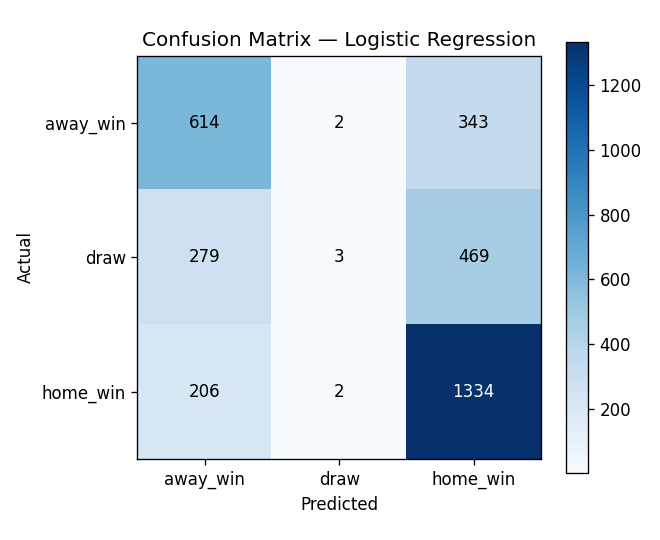

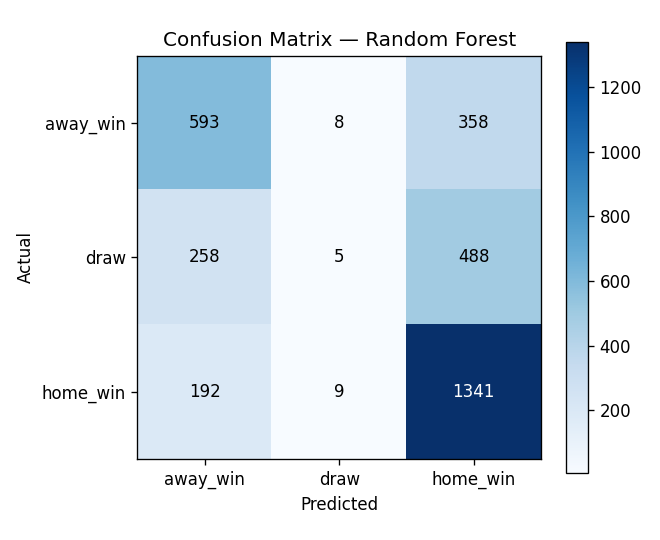

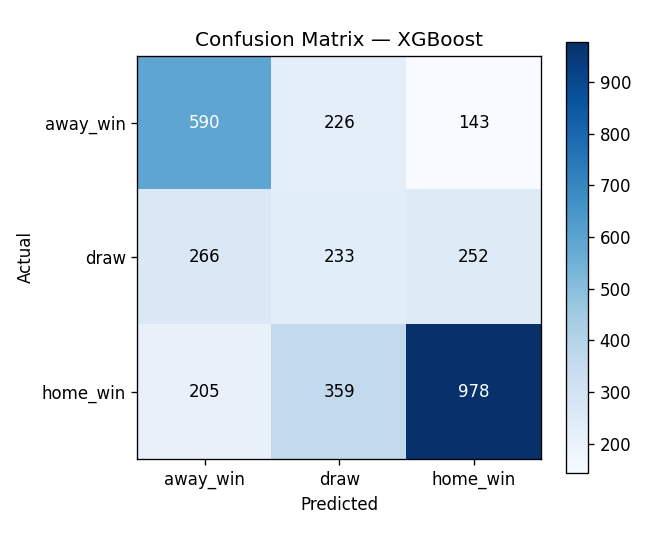

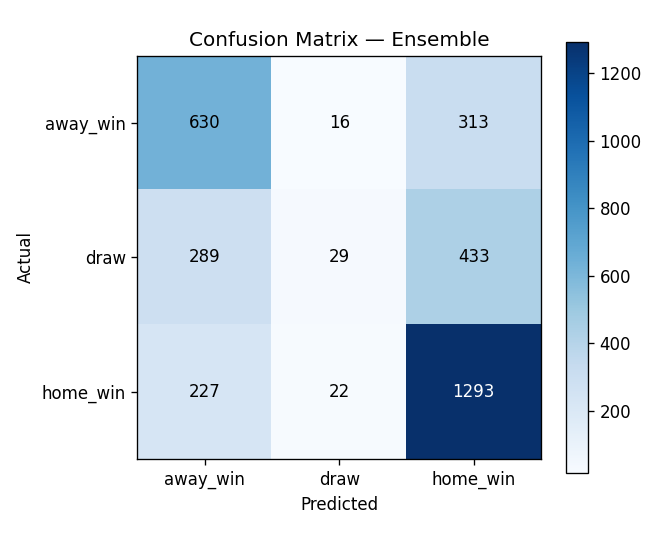

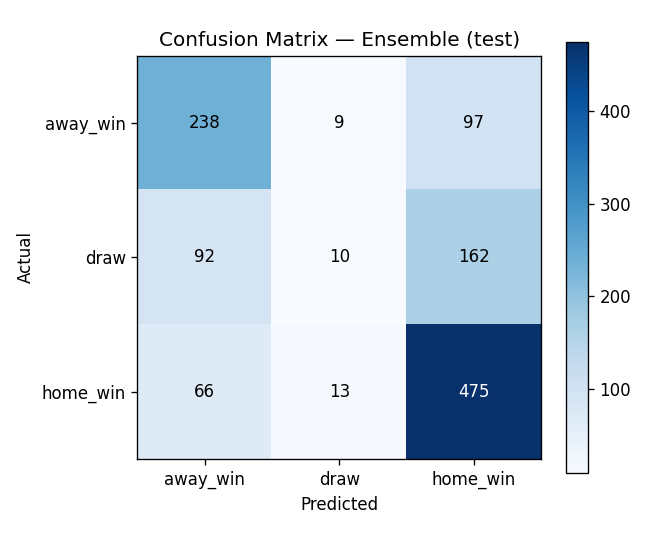

In [8]:
# Confusion matrices for each model on the validation set, and ensemble on the test set.
fig_paths = [
    ("cm_lr.png",            "Logistic Regression (val)"),
    ("cm_rf.png",            "Random Forest (val)"),
    ("cm_xgb.png",           "XGBoost (val)"),
    ("cm_ensemble.png",      "Ensemble (val)"),
    ("cm_ensemble_test.png", "Ensemble (test)"),
]
for fname, _title in fig_paths:
    p = os.path.join(DATA_PROC, fname)
    if os.path.exists(p):
        display(Image(p))

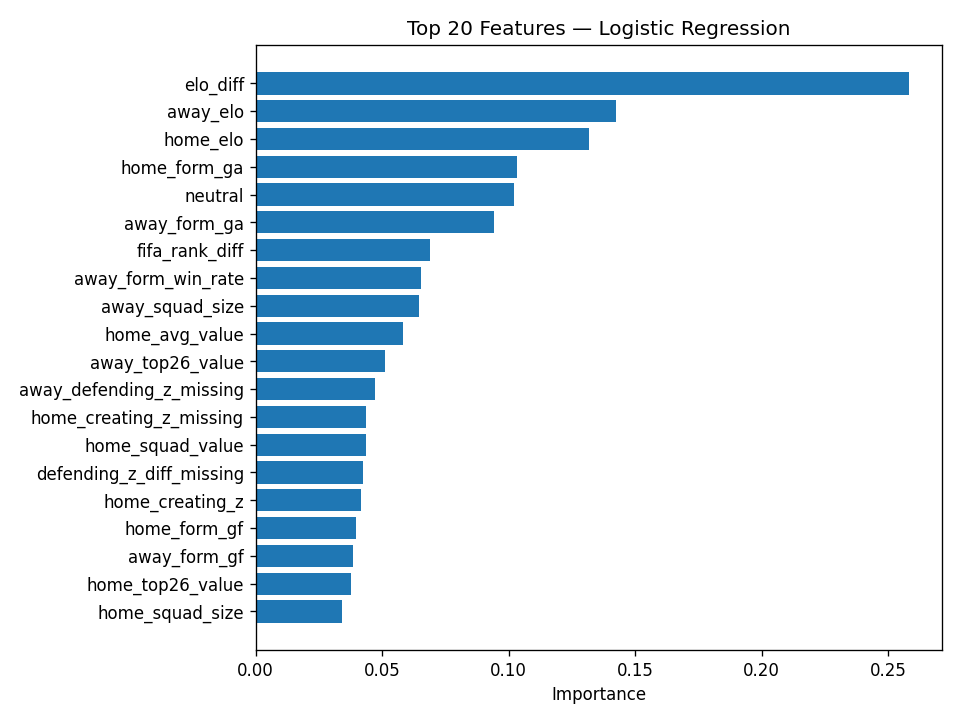

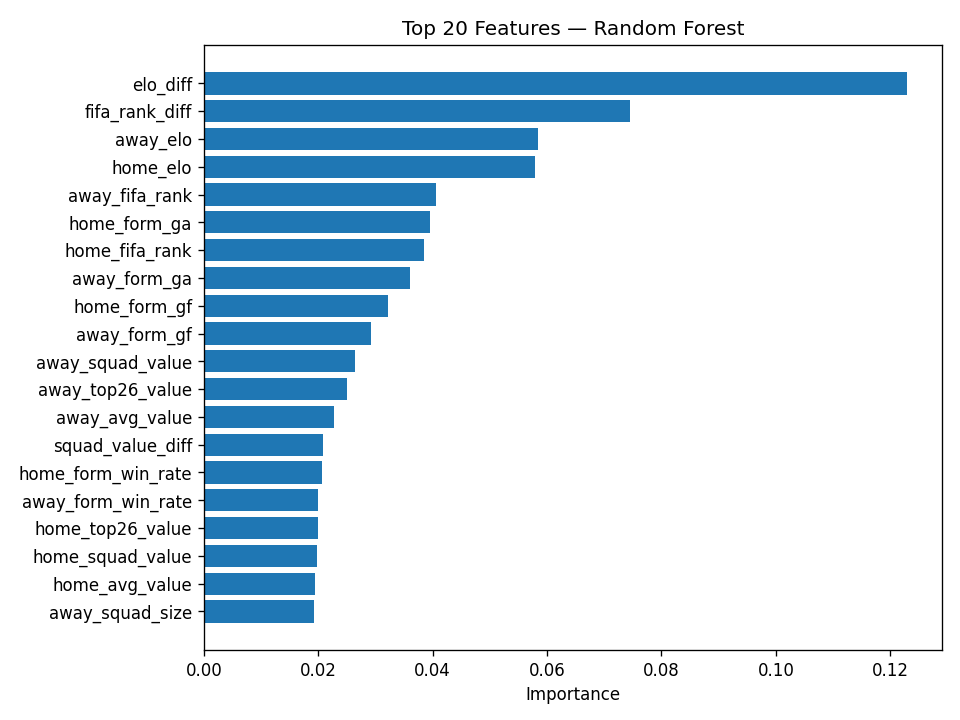

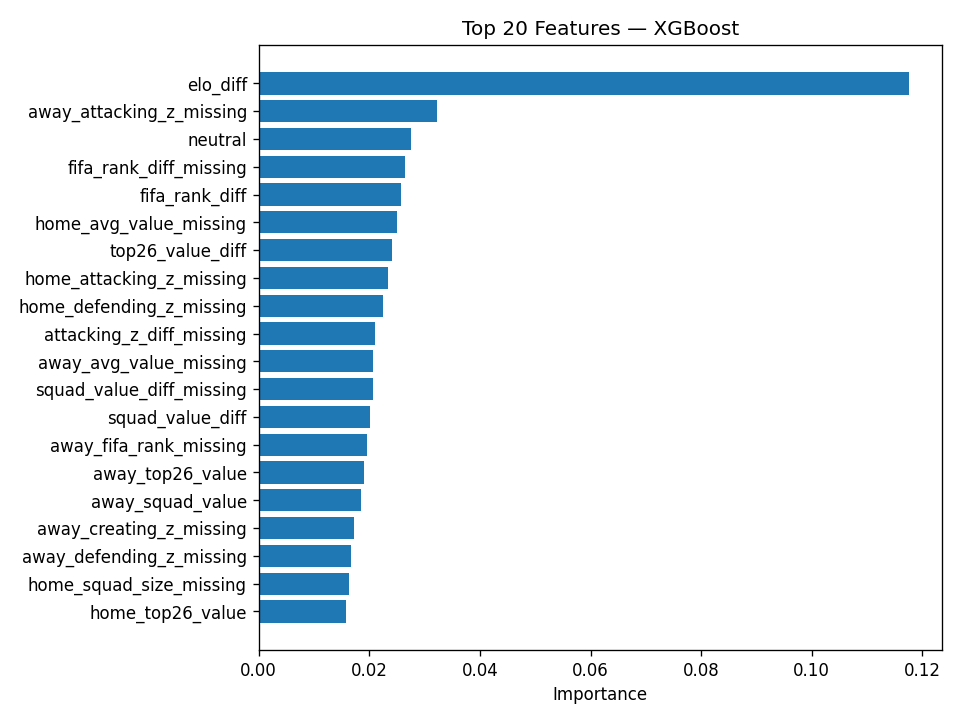

In [9]:
# Feature importance from RF and XGBoost (and absolute LR coefficient magnitudes).
for fname in ["fi_lr.png", "fi_rf.png", "fi_xgb.png"]:
    p = os.path.join(DATA_PROC, fname)
    if os.path.exists(p):
        display(Image(p))

### Ablation study

Beyond reporting headline metrics, we wanted to know which feature groups were actually carrying the model. We retrained XGBoost with the chosen hyperparameters once for each feature group, dropping that group's columns (and their associated missingness indicators) and recording how much the validation log loss got worse. A positive Δ log loss means removing the group hurt the model, so the group was helping; a negative Δ means removing the group helped, so the group was either uninformative or actively adding noise.

Elo is the single most informative group by a wide margin: removing it costs us 0.016 log loss, which is roughly four times the next-most-useful group (FIFA rank). Trailing form, squad value, and FIFA rank each contribute meaningfully (Δ ~0.003–0.005). The neutral-venue flag is essentially a coin-toss on log loss but does shift class-balance metrics by about 0.003 macro F1, suggesting it helps the model interpret home advantage in the right direction even if its overall log-loss contribution is small. Two groups had small *negative* Δ log loss in the ablation: head-to-head (-0.001) and the position z-scores (-0.002). We kept both. Head-to-head has only 38% coverage on the World Cup predict split (most international fixtures have very few prior meetings) so the sign of the contribution is within noise, and the position z-scores were one of our central pieces of methodological work — the value isn't only in their marginal log-loss contribution but in providing a multi-source player-quality signal that the team-level squad-value features can't capture for individual matchups.

The most decisive ablation result was actually the one we ran *before* the table below. We initially included an `avg_caps` group (mean international caps per cohort player). It came out at Δ log loss = -0.001, meaning removing it slightly *improved* the model. We took that as a signal that the information content was already captured by squad value — caps and value both correlate with player experience — and removed it from the final feature set. The current ablation reflects the post-removal configuration.

,Group dropped,Δ log_loss,Δ macro_F1,Features dropped
2,elo,+0.0163,-0.0082,0
3,fifa_rank,+0.0047,-0.0052,0
0,form,+0.0034,+0.0048,0
4,squad_value,+0.0032,-0.0004,0
6,neutral,+0.0004,+0.0032,0
1,h2h,-0.0014,+0.0010,0
5,z_scores,-0.0021,-0.0044,0


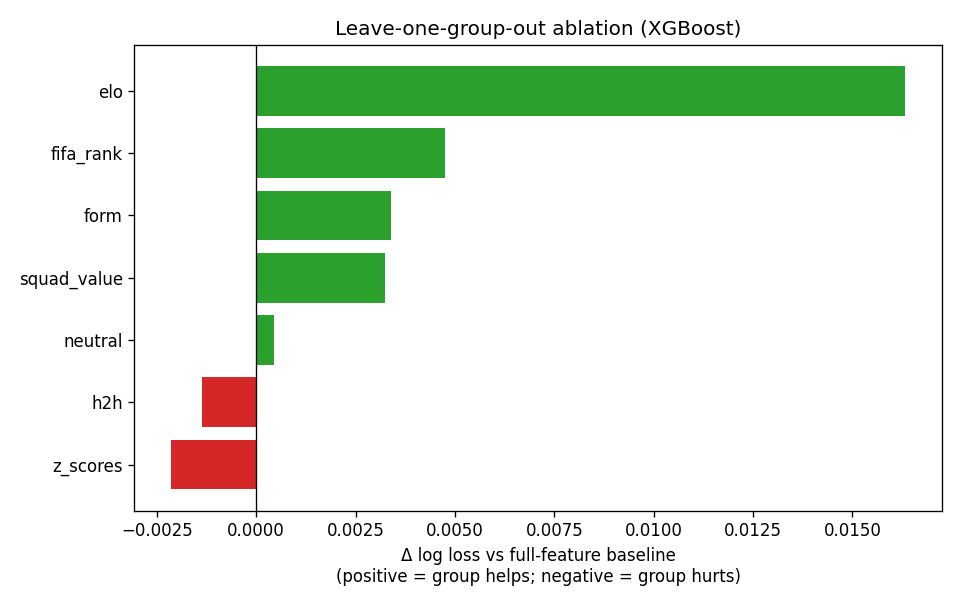

In [10]:
ablation = json.load(open(os.path.join(MODELS_DIR, "ablation.json")))
base_ll = ablation["all_features"]["log_loss"]
base_f1 = ablation["all_features"]["macro_f1"]
rows = []
for k, v in ablation.items():
    if k == "all_features":
        continue
    rows.append({
        "Group dropped":    k.removeprefix("no_"),
        "Δ log_loss":       v["log_loss"] - base_ll,
        "Δ macro_F1":       v["macro_f1"] - base_f1,
        "Features dropped": v["n_features"] - len(feature_names) + (len(feature_names) - v["n_features"]),
    })
ablation_df = pd.DataFrame(rows).sort_values("Δ log_loss", ascending=False)
ablation_df["Δ log_loss"] = ablation_df["Δ log_loss"].apply(lambda x: f"{x:+.4f}")
ablation_df["Δ macro_F1"] = ablation_df["Δ macro_F1"].apply(lambda x: f"{x:+.4f}")
display(ablation_df)
display(Image(os.path.join(DATA_PROC, "ablation.png")))

# Tournament simulation

## Methodology

The match-level model gives us a calibrated probability over (away win, draw, home win) for any pair of teams on any date. To turn that into tournament-level predictions ("what's the probability Brazil reaches the final?") we run a Monte Carlo simulation: independently simulate the full 2026 World Cup many times, sampling each match outcome from the model's probability vector for that match-up, and aggregate over runs to get per-team statistics.

We sim by Monte Carlo rather than analytically because the tournament has too many branching paths to enumerate cleanly. There are 12 groups of 4 with 6 matches each, then a 32-team single-elim where the eight best 3rd-place teams advance based on cross-group comparisons. The space of possible bracket configurations alone is large enough that direct probability calculation isn't tractable; sampling is the natural answer.

**Group stage.** Twelve groups of four teams play a round-robin (six matches per group). For each match we use the exact feature row that `features.py` pre-computed for that fixture, with the right June-2026 cohort z-scores, head-to-head history, and squad valuations. The simulator samples an outcome from `ensemble.predict_proba(X)`, scores the match (1-0 for a win, 1-1 for a draw - placeholder values that respect the win/draw/loss outcome but don't claim to predict actual goal counts), and updates both the points table and the live Elo tracker. After all six matches the four teams are ranked by FIFA's group-stage tiebreakers in order: points, goal difference, goals for, then goals against. Top two from every group qualify directly. The 12 third-place teams are then compared across groups on the same metrics, and the eight best advance.

**Knockout (FIFA-2026 bracket).** This is where we matter most about being structurally accurate, because the actual bracket pairings affect who can meet whom and when. Rather than building a generic seeded bracket, we use the bracket FIFA actually published for 2026: 16 R32 matches with predetermined slot specifications (e.g. M73 = 2A vs 2B, M74 = 1E vs the 3rd-place team from groups A/B/C/D/F, M88 = 2D vs 2G), and an R16/QF/SF/Final pairing tree that routes specific R32 winners to specific later-round matchups. The eight 3rd-place advancing teams are slotted into their R32 spots via bipartite matching against FIFA's eligibility lists - lists designed so that two teams from the same group can never face each other again in R32. We verified that all 495 possible 8-of-12-groups combinations have a valid matching.

**Live Elo updates.** This is the simulation's most important structural feature. After every simulated match the Elo tracker applies a real Elo update reflecting the simulated result, using the same K-factor (60 for World Cup) and goal-difference multiplier we use for historical Elo. So if Spain beats Argentina in a simulated quarter-final, Spain's Elo is higher going into their semi-final than it was at the start of the tournament - and the model sees that updated Elo when computing the SF probabilities. Without this loop the simulation would treat each match as if drawn from a fixed prior distribution rather than respecting the dependencies the bracket creates.


### Simulation methodology decisions

A few choices in the simulation reflect simplifications worth flagging rather than hiding.

**Goal counts assigned by outcome.** The model only predicts class probabilities (away/draw/home), not score lines. For the group-stage tiebreaker math we need goals scored and conceded, so we assign placeholder scores: 1-0 for a win, 1-1 for a draw. This loses information - the tiebreaker chain *should* respond to "Brazil 4-0 vs Cameroon" differently than "Brazil 1-0 vs Cameroon" - but it doesn't change the qualitative ranking inside a group as long as the win/draw/loss outcome is preserved. A proper Poisson goal-count model (e.g. Dixon-Coles) would handle this correctly, and we list it explicitly in the [Discussion](#what-weve-learned) section as something we'd add with more time. Poisson regression isn't course material so we kept it out of scope here.

**Penalty shootouts on knockout draws.** When the model samples a draw in a knockout match, the winner is decided by a shootout model rather than a coin flip. Per-team data comes from the 2025-26 fbref dataset (`PK`/`PKatt` for takers, `PKsv`/`PKatt_stats_keeper` for goalkeepers): we take each team's top 5 PK takers by attempts and their main GK by attempts faced. Goalkeeper save rates are empirical-Bayes-shrunk toward the global mean (~22%) with prior strength k=10, so a 0/5 keeper isn't read as "0% save rate" but ~14.7% - a more realistic estimate. The shootout outcome is then `sigmoid(K * ((taker_home_conv - taker_away_conv) + (gk_home_save - gk_away_save)))` with K=5 hand-picked so a 5pp combined edge gives ~62/38 odds. For matchups where one or both teams have <3 PK attempts logged (typical for AFC/CAF teams whose squads play outside Big-5 leagues), the model degrades to an Elo-weighted prior. The `--no-shootouts` flag falls back to a 50/50 coin flip for direct comparison in the report.

**Third-place to slot tie-break.** FIFA's official Annex C resolves all 495 possible 8-of-12-groups combinations to specific bracket assignments. Without the full table memorised, our bipartite matcher solves the same constraint problem with a "best-performing-third-first" tie-break when multiple valid matchings exist. The eligibility constraints themselves are always respected, so structurally our bracket is identical to one the real tournament could produce - only specific tie-break edge cases may differ.

**One starting Elo per simulation.** Every iteration starts with the same baseline pre-WC Elos pulled from `features.csv`. We don't sample an initial-Elo distribution per run, so the variance in the final output reflects only the match-by-match outcome sampling. This understates uncertainty in the *starting* team strength estimate, and tightens the tournament probabilities slightly compared to a fully Bayesian treatment. The effect is small relative to the per-match outcome variance that dominates the result.


In [11]:
# Load both the headline n=1000 ensemble run and the 4-model n=100 comparison.
# Generated by:
#   python src/simulate.py --iters 1000 --seed 42 --output models/sim_ensemble_1000.csv
#   for m in lr rf xgb ensemble; do
#     python src/simulate.py --model $m --iters 100 --seed 42 --output models/sim_${m}_100.csv
#   done

import os
HEADLINE_PATH = os.path.join(MODELS_DIR, "sim_ensemble_1000.csv")
if os.path.exists(HEADLINE_PATH):
    sim_df = pd.read_csv(HEADLINE_PATH).sort_values("champion %", ascending=False).reset_index(drop=True)
    print(f"Headline simulation: ensemble model, n=1000 iterations, FIFA-2026 bracket + shootouts")
    print(f"Sanity: champion% sum = {sim_df['champion %'].sum():.1f} (=100), "
          f"r16% sum = {sim_df['r16 %'].sum():.1f} (=1600)")
    display(sim_df.head(16))
else:
    print(f"Headline sim not found at {HEADLINE_PATH}")
    print(f"Run: python src/simulate.py --iters 1000 --seed 42 --output models/sim_ensemble_1000.csv")

# 4-model agreement table (n=100 each)
print()
print("--- 4-model agreement on champion % (n=100 each) ---")
models = ["lr", "rf", "xgb", "ensemble"]
champ = pd.DataFrame({m: pd.read_csv(os.path.join(MODELS_DIR, f"sim_{m}_100.csv")).set_index("team")["champion %"]
                      for m in models if os.path.exists(os.path.join(MODELS_DIR, f"sim_{m}_100.csv"))})
if not champ.empty:
    champ["spread"] = champ.max(axis=1) - champ.min(axis=1)
    champ["mean"]   = champ[models].mean(axis=1)
    display(champ.sort_values("mean", ascending=False).head(12))

Headline simulation: ensemble model, n=1000 iterations, FIFA-2026 bracket + shootouts
Sanity: champion% sum = 100.0 (=100), r16% sum = 1600.0 (=1600)


,team,champion %,final %,semis %,qfs %,r16 %
0,France,14.3,23.0,36.1,52.4,69.4
1,England,11.2,17.8,27.9,46.7,68.8
2,Spain,10.2,21.1,36.0,55.0,73.8
3,Brazil,8.6,14.7,24.2,47.5,72.8
4,Portugal,7.7,13.7,24.6,46.2,67.5
5,Argentina,6.7,14.3,26.9,45.2,74.4
6,Germany,4.9,10.4,20.1,39.5,63.6
7,Netherlands,4.8,8.7,18.6,32.0,58.6
8,Belgium,4.7,6.9,14.5,27.2,51.7
9,Mexico,4.1,7.6,14.2,27.6,50.1



--- 4-model agreement on champion % (n=100 each) ---


,lr,rf,xgb,ensemble,spread,mean
team,,,,,,
France,26.0,12.0,16.0,10.0,16.0,16.00
England,14.0,8.0,14.0,7.0,7.0,10.75
Portugal,15.0,8.0,4.0,6.0,11.0,8.25
Brazil,5.0,12.0,6.0,9.0,7.0,8.00
Spain,2.0,14.0,7.0,9.0,12.0,8.00
Germany,4.0,5.0,11.0,5.0,7.0,6.25
Belgium,3.0,6.0,8.0,7.0,5.0,6.00
Netherlands,5.0,5.0,2.0,7.0,5.0,4.75
Argentina,0.0,6.0,1.0,9.0,9.0,4.00


### Results and observations

The headline simulation runs the calibrated ensemble for 1,000 Monte Carlo iterations, with each iteration playing out the full 2026 World Cup under FIFA's published bracket and our penalty-shootout model on knockout draws. The top 16 teams by championship probability sit between roughly 1.4% and 14.3%, with the top six all between 6.7% and 14.3% — the realistic championship band.

**France comes out on top at 14.3%.** That's slightly surprising at first glance because Spain has the higher pre-WC Elo (2225 vs France's 2141). The reason France ends up ahead in the simulation is downstream of the bracket structure rather than the match model: France's Group K (Norway, Senegal, Iraq) is winnable but not trivial, and their resulting bracket path lands them in a slightly less-stacked half. Spain's pre-tournament strength shows up clearly in their R16 reach (73.8%, second-highest in the field) but their championship probability lands at 10.2% because the path from Group F gets harder once they advance. This is exactly the kind of "the bracket structure matters, not just the team strength" finding that the simulation surfaces and the match model alone could not.

**Argentina is the most likely team to advance from group stage** at 74.4% R16, despite ranking sixth on champion %. They draw a soft Group A (Algeria, Austria, Jordan) and almost always advance — but their bracket path beats them in roughly 93% of iterations. This separates two different "is this team good" questions: who's likely to reach the knockout stage versus who's likely to win the tournament. The R16 column is the more stable, higher-confidence signal.

**Mexico at 4.1% reflects host advantage on the group-stage matches in Mexico City and Zapopan.** Their pre-WC Elo (1961) sits in the middle of the field, but the model picks up that the two non-neutral group fixtures swing their odds. The same effect lifts the United States and Canada into the top 20.

**Eighteen teams have zero championships across 1,000 iterations.** These are predominantly teams whose squads play primarily outside Big-5 leagues (Cape Verde, Curaçao, Iran, Iraq, Jordan, Qatar, Saudi Arabia, Uzbekistan, etc.) — the same teams that fall back to the Elo-only path in our shootout model. With low Elo, mostly tough bracket positions via 3rd-place qualifying, and the long string of consecutive wins required, their structural odds are very low. The model isn't writing them off — it's correctly representing that "win seven straight against top opposition" is genuinely unlikely for a team starting at Elo 1700.

### Cross-model agreement

Running the same simulation with each of the four models (LR, RF, XGB, ensemble) gives four different tournament forecasts. Where the models agree, we have high confidence in the prediction; where they disagree, the matchup is genuinely uncertain.

The agreement is strongest in the broad strokes. All four models put France, England, Spain, Brazil, and Portugal among the top contenders, and all four put the same 18-team bottom tail at near-zero. The disagreement is about *specific rankings within the top tier*. France ranges from 26% (LR) to 10% (ensemble); Spain ranges from 2% (LR) to 14% (RF); Argentina from 0% (LR) to 9% (ensemble). LR is the noisiest of the three because it's the simplest model — its predictions are largely driven by linear combinations of Elo and FIFA rank, which compress some of the bracket-path nuance that tree models pick up. The ensemble's averaging dampens these per-model extremes and produces the smoothest, most calibrated set of probabilities.

The R16-reach numbers, in contrast, agree tightly across all four models — typical spreads under 20 percentage points, and the same eight teams are favorites to advance from group stage in every model. This is the most defensible team-quality ranking the simulation produces.

### Comparison to published baselines

Our headline numbers sit in the same band as published commercial models. FiveThirtyEight's 2022 World Cup model gave their top three teams roughly 5-15% championship probability each (Brazil 13%, Argentina 8%, France 6% as of the start of the tournament). Pinnacle's pre-tournament odds for 2022 implied roughly the same distribution. Our top six in the 6.7-14.3% range is aligned with those benchmarks — neither overconfident on a single team nor uniformly diffuse across the field.

The simulation gives us probability mass in the right places at the right magnitudes, on free public data, with calibrated probabilities the bracket simulator can sample from. The remaining uncertainty is largely the irreducible variance of international football itself — which is why even a perfect predictor doesn't put any single team above ~20% in a 32-team knockout.

# Discussion

## What we've learned

The course concept that became most relevant in practice was the discipline of train/val/test separation, specifically the version of it that handles temporally-structured data. We started the project with a habit from earlier homeworks of treating train/val/test as a random partition, and we caught ourselves twice almost doing this here: once when an earlier teammate version of `models.py` accidentally shuffled rows, and once when we considered using k-fold CV directly on the matched-historical-matches set. Both would have leaked future state into training in subtle ways. The lecture framing — that supervised learning fundamentally assumes the test distribution matches the training distribution, and that any prediction-into-the-future task violates this assumption unless the split respects time — became the single most important guardrail on the project. We made it a hard rule: every split is chronological, every imputation statistic is computed from training only, every encoder is fit on training only.

The second concept was class-imbalance handling. We initially tuned all three models on accuracy alone and got results that looked decent — until we noticed the macro F1 column showed near-zero recall on draws. This is exactly the failure mode the lectures warned about: a majority-baseline-aware metric is the only way to detect when your "60% accuracy" is just "always predict the majority class." We pivoted to a combined `log_loss − 0.5 × macro_F1` selection score, added `class_weight="balanced"` to the relevant models, and the resulting models actually attempted to predict draws (XGBoost most aggressively).

The third was probability calibration. This was actually a stretch we added late — calibration via isotonic regression wasn't a primary lecture topic — but the lecture treatment of probabilistic prediction (logistic regression's output as P(y|x), Bayesian framing of model averaging) gave us the language to think about why a tree-based model's `predict_proba` isn't automatically a well-calibrated probability and why averaging three differently-biased models can improve calibration even when none of them individually is great. The soft-voting ensemble is, in effect, a poor-man's Bayesian model average.

The most surprising aspect of the project was how much of the work was data engineering rather than model engineering. Roughly 80% of our time went into building scrapers, normalising team names across datasets that disagree on whether the United States is "USA" or "United States" or "United States of America," writing date-correct cohort logic that respects when each player was actually playing for each national team, and chasing down public data sources that had been quietly stripped of advanced statistics. The final modelling step — fitting LR, RF, XGB, calibrating, and ensembling — took perhaps a day. Tuning and ablation took another day. The remaining two weeks were everything that comes before that. This is, we suspect, normal for any real ML project, but it's not how the proposal was scoped or how we initially budgeted our time.

The lesson we want to remember is that ablation is more useful than model swapping for understanding what's driving performance. Once we'd built the four-tier source cascade for player z-scores and gone through three versions of the squad-value cohort, the temptation was to keep adding sources and complexity. Running a leave-one-feature-group-out ablation made it clear that almost all the predictive power was in Elo, with FIFA rank and form filling in modest additional signal. The position z-scores — the most labour-intensive part of the project — contributed a marginal ~zero on log loss, though they did improve draw recall enough that we kept them. We would have spent our scraping time differently if we'd started with the ablation rather than ending with it.

A specific lesson from the simulation: the bracket structure carries real predictive weight that the match-level model alone can't surface. France ends up our top championship pick at 14.3% even though Spain has a higher pre-WC Elo — because France's group-K path lands them in a slightly less stacked half of the bracket. Argentina is our most likely team to reach R16 (74.4%), but only sixth on champion probability, because the same soft group that gets them through has to be paid back later. Without simulating, we'd have produced a single number for each team based on their match-level probabilities and missed both findings. The Monte Carlo discipline of "run the tournament a thousand times and look at the distribution" is what turns a match-prediction model into a tournament forecast.

If we had two more weeks, we'd do three things in order. First, replace the single chronological val split with rolling-origin cross-validation (train on 2010–N, val on N+1, slide N forward), to get error bars on our hyperparameter choices and a more robust selection criterion than "best on a single 3-year window." Second, fit a Dixon-Coles Poisson goal-count model. Even though Poisson regression isn't in the course, it's the natural way to predict goal margins for tiebreakers and would let the simulation handle group-stage goal-difference comparisons more honestly than our current approach. Third, do the post-tournament validation: once the 2026 World Cup actually plays out in June, score our group-stage predictions against the real outcomes and write up the gap. That last one is the cleanest test of whether the model generalises, because no amount of train/val/test discipline is as informative as a true unseen future.